## ESM-FCN vs ESM-FCN_BE

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_log_file(metrics_csv_be, metrics_csv_b, metrics_csv_e, coords, metrics_img):
    df_be = pd.read_csv(metrics_csv_be)
    df_b = pd.read_csv(metrics_csv_b)
    df_e = pd.read_csv(metrics_csv_e)

    sns.set_theme(style="darkgrid")
    fig, ((ax_tr_be, ax_tr), (ax_te_be, ax_te)) = plt.subplots(2, 2, figsize=(16, 9))  # 1 rows, 2 columns
    fontsize = 16

    # Plot 1: Training BE Metrics
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr_be.tick_params(axis='x', bottom=False, labelbottom=False)    
    ax_tr_be.set_xlim(-50, 1050)
    ax_tr_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_tr_be.tick_params(axis='y', labelsize=fontsize)
    ax_tr_be.set_ylim(-0.1, 1.3)
    ax_tr_be.legend(title='Training (Combined)', loc='upper right', frameon=False)

    # Plot 2: Testing BE Metrics
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te_be.set_xlabel('Epochs', fontsize=fontsize)
    ax_te_be.tick_params(axis='x', labelsize=fontsize)
    ax_te_be.set_xlim(-50, 1050)
    ax_te_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_te_be.tick_params(axis='y', labelsize=fontsize)
    ax_te_be.set_ylim(-0.1, 1.3)
    ax_te_be.legend(title='Testing (Combined)', loc='upper right', frameon=False)

    # Plot 3: Training Metrics
    ax_tr.plot(df_b['Epoch'], df_b[f'Train RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr.plot(df_e['Epoch'], df_e[f'Train RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr.tick_params(axis='x', bottom=False, labelbottom=False)   
    ax_tr.set_xlim(-50, 1050)
    ax_tr.tick_params(axis='y', left=False, labelleft=False)
    ax_tr.set_ylim(-0.1, 1.3)
    ax_tr.legend(title='Training (Separate)', loc='upper right', frameon=False)

    # Plot 4: Testing Metrics
    ax_te.plot(df_b['Epoch'], df_b[f'Test RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te.plot(df_e['Epoch'], df_e[f'Test RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te.set_xlabel('Epochs', fontsize=fontsize)
    ax_te.tick_params(axis='x', labelsize=fontsize)
    ax_te.set_xlim(-50, 1050)
    ax_te.tick_params(axis='y', left=False, labelleft=False)
    ax_te.set_ylim(-0.1, 1.3)
    ax_te.legend(title='Testing (Separate)', loc='upper right', frameon=False)

    # Plot Best Test Loss
    best_df_be_b_rmse = find_best_epoch(metrics_csv_be, f'Test Binding RMSE')
    best_df_be_e_rmse = find_best_epoch(metrics_csv_be, f'Test Expression RMSE')
    best_df_b_rmse = find_best_epoch(metrics_csv_b, f'Test RMSE')
    best_df_e_rmse = find_best_epoch(metrics_csv_e, f'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"\tBE Binding: epoch {best_df_be_b_rmse[0]}, rmse {best_df_be_b_rmse[1]:.4f}")
    print(f"\tBE Expression: epoch {best_df_be_e_rmse[0]}, rmse {best_df_be_e_rmse[1]:.4f}")
    print(f"\tBinding: epoch {best_df_b_rmse[0]}, rmse {best_df_b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df_e_rmse[0]}, rmse {best_df_e_rmse[1]:.4f}")

    ax_te_be.annotate(
        f'({best_df_be_b_rmse[0]}, {best_df_be_b_rmse[1]:.4f})', best_df_be_b_rmse, 
        textcoords="offset points", xytext=(coords['BE Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te_be.annotate(
        f'({best_df_be_e_rmse[0]}, {best_df_be_e_rmse[1]:.4f})', best_df_be_e_rmse, 
        textcoords="offset points", xytext=(coords['BE Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_b_rmse[0]}, {best_df_b_rmse[1]:.4f})', best_df_b_rmse, 
        textcoords="offset points", xytext=(coords['Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_e_rmse[0]}, {best_df_e_rmse[1]:.4f})', best_df_e_rmse, 
        textcoords="offset points", xytext=(coords['Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

Comparing: best ESM-FCN_BE binding and expression vs best ESM-FCN binding and best ESM-FCN expression.

Best test RMSE at epoch x:
	BE Binding: epoch 72, rmse 0.5005
	BE Expression: epoch 988, rmse 0.3102
	Binding: epoch 965, rmse 0.5185
	Expression: epoch 233, rmse 0.3145


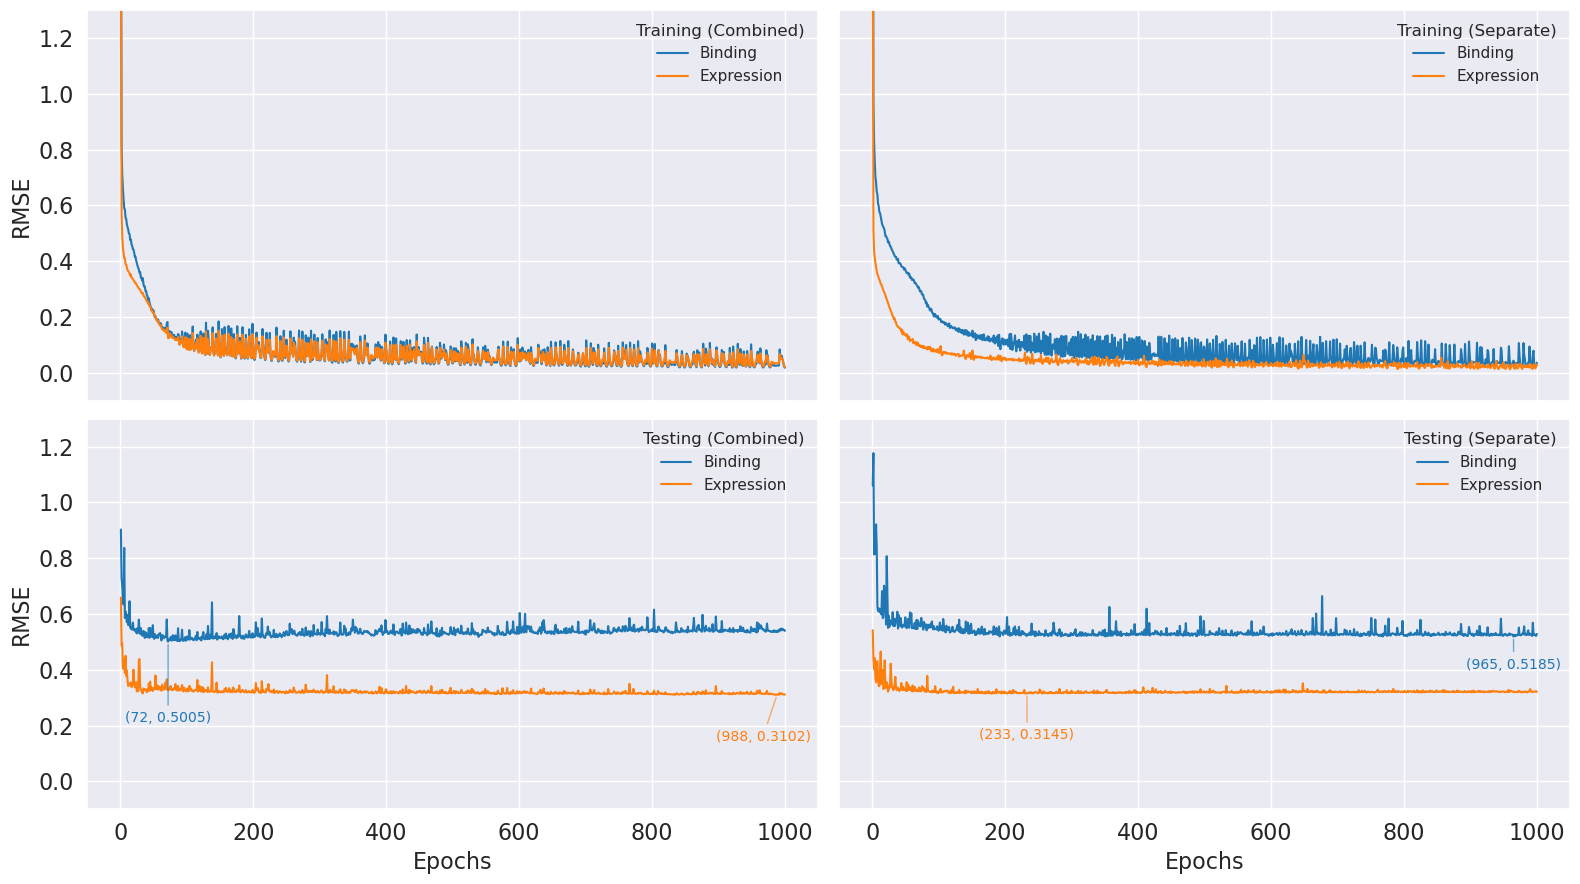

In [6]:
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/esm_fcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"

coords = {
    "BE Binding": (0,-50),
    "BE Expression": (-10,-25),
    "Binding": (0,-15),
    "Expression": (0,-25)
}

comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/best_esm-fcn_BE.vs.best_esm-fcn"
plot_comparative_log_file(be_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, coords, f"{comparison_file}.model_comp.pdf")

---
## R^2 Values - Getting the predicted values
We need to get the R^2 values from all available ESM-FCN models. To do this, we need to get the predicted values from the best saved model.

In [7]:
import os
import sys
import tqdm
import time
import torch
import random
import datetime
import pandas as pd
import numpy as np
from typing import Union
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel

def load_model(saved_model_pth, device):
    saved_state = torch.load(saved_model_pth, map_location=device)

    model_state = saved_state['model_state_dict']
    optimizer_state = saved_state['optimizer_state_dict']

    epoch = saved_state['epoch']
    loss = saved_state['loss']

    print(f"Loaded in model from {saved_model_pth}, saved at epoch {epoch}, rmse loss {loss}")
    return model_state, optimizer_state, epoch, loss

class DMSDataset(Dataset):
    """ Binding or Expression DMS Dataset, single target. """
    
    def __init__(self, csv_file:str, result_tag:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding or expression target,
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
            self.target = 'ACE2-binding_affinity' if 'binding' in result_tag else 'RBD_expression'
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df[self.target][idx]
    
class DMSDataset_BE(Dataset):
    """ Binding and Expression DMS Dataset, multi target. """
    
    def __init__(self, csv_file:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding target,
        - expression target
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, binding target, expression target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df['ACE2-binding_affinity'][idx], self.full_df['RBD_expression'][idx]

### Non BE Models

In [8]:
class FCN(nn.Module):
    """ Fully Connected Network """

    def __init__(self,
                 fcn_input_size,    # The number of input features
                 fcn_hidden_size,   # The number of features in hidden layer of FCN.
                 fcn_num_layers):   # The number of fcn layers  
        super().__init__()

        # Creating a list of layers for the FCN
        # Subsequent layers after 1st should be equal to hidden_size for input_size
        layers = []
        input_size = fcn_input_size

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(input_size, fcn_hidden_size))
            layers.append(nn.ReLU())
            input_size = fcn_hidden_size

        # FCN layers
        self.fcn = nn.Sequential(*layers)

        # FCN output layer 
        self.out = nn.Linear(fcn_hidden_size, 1)

    def forward(self, x):
        fcn_out = self.fcn(x)
        prediction = self.out(fcn_out).squeeze(1)  # [batch_size]
        
        return prediction

# ESM-FCN
class ESM_FCN(nn.Module):
    def __init__(self, esm, fcn):
        super().__init__()
        self.esm = esm
        self.fcn = fcn

    def forward(self, x):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**x).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_cls_embedding = esm_last_hidden_state[:, 0, :]  # CLS token embedding (sequence-level representations), [batch_size, embedding_dim]
            output = self.fcn(esm_cls_embedding)
        return output
    
# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as_dir: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "predicted_value":[],
        "mode": []
    }

    rmse_dict = {
        "seq_id": [],
        "mse": [],
        "rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        preds = model(tokenized_seqs)
        batch_losses = loss_fn(preds, targets)
        batch_loss = sum(batch_losses)
        batch_loss.backward()

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("train")

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            preds = model(tokenized_seqs)
            batch_losses = loss_fn(preds, targets)

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("test")

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("test")

    prediction_df = pd.DataFrame.from_dict(prediction_dict)
    prediction_df.to_csv(os.path.join(save_as_dir, f"all_predicted_values_best_saved.csv"), index=False)
    #print(f"Predictions:\n {prediction_df}")

    rmse_df = pd.DataFrame.from_dict(rmse_dict)
    rmse_df.to_csv(os.path.join(save_as_dir, f"all_rmse_best_saved.csv"), index=False)
    #print(f"RMSEs:\n {rmse_df}")

In [9]:
# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# FCN input
size = 320
fcn_input_size = size  
fcn_hidden_size = size
fcn_num_layers = 5
fcn = FCN(fcn_input_size, fcn_hidden_size, fcn_num_layers)

model = ESM_FCN(esm, fcn)

# Data/results directories
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_fcn'

# Run
print("== BINDING ==")
result_tag = 'binding' 
run_dir_binding4 = os.path.join(results_dir, f'adam.lr1e-04.esm_fcn-DMS_OLD-binding-2024-12-05_04-12')
saved_model_pth_binding4 = os.path.join(run_dir_binding4, "best_saved_model.pth")

run_dir_binding5 = os.path.join(results_dir, f'adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54')
saved_model_pth_binding5 = os.path.join(run_dir_binding5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

print("> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_binding4, saved_model_pth_binding4)

print("> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_binding5, saved_model_pth_binding5)


print("== EXPRESSION ==")
result_tag = 'expression' 
run_dir_expression4 = os.path.join(results_dir, f'adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15')
saved_model_pth_expression4 = os.path.join(run_dir_expression4, "best_saved_model.pth")

run_dir_expression5 = os.path.join(results_dir, f'adam.lr1e-05.esm_fcn-DMS_OLD-expression-2024-12-04_17-56')
saved_model_pth_expression5 = os.path.join(run_dir_expression5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

print("> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_expression4, saved_model_pth_expression4)

print("> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_expression5, saved_model_pth_expression5)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


== BINDING ==
> LR = 1e-04
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-binding-2024-12-05_04-12/best_saved_model.pth, saved at epoch 76, rmse loss 0.5234799531502154


Testing data: 100%|| 322/322 [00:15<00:00, 20.55it/s]


> LR = 1e-05
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/best_saved_model.pth, saved at epoch 965, rmse loss 0.518519043711583


Testing data: 100%|| 322/322 [00:15<00:00, 20.44it/s]


== EXPRESSION ==
> LR = 1e-04
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/best_saved_model.pth, saved at epoch 233, rmse loss 0.31447367012676647


Testing data: 100%|| 322/322 [00:15<00:00, 20.51it/s]


> LR = 1e-05
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-expression-2024-12-04_17-56/best_saved_model.pth, saved at epoch 985, rmse loss 0.31718101309978286


Testing data: 100%|| 322/322 [00:15<00:00, 20.54it/s]


### BE Models

In [10]:
class FCN(nn.Module):
    """ Fully Connected Network """

    def __init__(self,
                 fcn_input_size,    # The number of input features
                 fcn_hidden_size,   # The number of features in hidden layer of FCN.
                 fcn_num_layers):   # The number of fcn layers  
        super().__init__()

        # Creating a list of layers for the FCN
        # Subsequent layers after 1st should be equal to hidden_size for input_size
        layers = []
        input_size = fcn_input_size

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(input_size, fcn_hidden_size))
            layers.append(nn.ReLU())
            input_size = fcn_hidden_size

        # FCN layers
        self.fcn = nn.Sequential(*layers)

        # FCN output layers - two separate heads for binding and expression
        self.binding_head = nn.Linear(fcn_hidden_size, 1)
        self.expression_head = nn.Linear(fcn_hidden_size, 1)

    def forward(self, x):
        fcn_out = self.fcn(x)

        # Task-specific predictions
        binding_pred = self.binding_head(fcn_out).squeeze(1) # [batch_size]
        expression_pred = self.expression_head(fcn_out).squeeze(1) # [batch_size]

        return binding_pred, expression_pred

# ESM-FCN
class ESM_FCN(nn.Module):
    def __init__(self, esm, fcn):
        super().__init__()
        self.esm = esm
        self.fcn = fcn

    def forward(self, tokenized_seqs):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_cls_embedding = esm_last_hidden_state[:, 0, :]  # CLS token embedding (sequence-level representations), [batch_size, embedding_dim]
            binding_preds, expression_preds = self.fcn(esm_cls_embedding) # [batch_size]
        return binding_preds, expression_preds

# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as_dir: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "binding_predicted_value":[],
        "expression_predicted_value":[],
        "mode": []
    }

    rmse_dict = {
        "seq_id": [],
        "binding_mse": [],
        "binding_rmse": [],
        "expression_mse": [],
        "expression_rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        binding_preds, expression_preds = model(tokenized_seqs)
        batch_binding_losses = loss_fn(binding_preds, binding_targets)
        batch_expression_losses = loss_fn(expression_preds, expression_targets)
        batch_binding_loss = sum(batch_binding_losses)
        batch_expression_loss = sum(batch_expression_losses)
        batch_be_loss = batch_binding_loss + batch_expression_loss
        batch_be_loss.backward()

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("train")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            binding_preds, expression_preds = model(tokenized_seqs)
            batch_binding_losses = loss_fn(binding_preds, binding_targets)
            batch_expression_losses = loss_fn(expression_preds, expression_targets)

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("test")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("test")

    prediction_df = pd.DataFrame.from_dict(prediction_dict)
    prediction_df.to_csv(os.path.join(save_as_dir, f"all_predicted_values_best_saved.csv"), index=False)
    #print(f"Predictions:\n {prediction_df}")

    rmse_df = pd.DataFrame.from_dict(rmse_dict)
    rmse_df.to_csv(os.path.join(save_as_dir, f"all_rmse_best_saved.csv"), index=False)
    #print(f"RMSEs:\n {rmse_df}")

In [11]:
# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_fcn'

run_dir4 = os.path.join(results_dir, f'adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46')
saved_model_pth4 = os.path.join(run_dir4, "best_saved_model.pth")

run_dir5 = os.path.join(results_dir, f'adam.lr1e-05.esm_fcn_BE-DMS_OLD-2025-01-01_22-45')
saved_model_pth5 = os.path.join(run_dir5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"))
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"))
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# FCN input
size = 320
fcn_input_size = size  
fcn_hidden_size = size
fcn_num_layers = 5
fcn = FCN(fcn_input_size, fcn_hidden_size, fcn_num_layers)

model = ESM_FCN(esm, fcn)

# Run
print("> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir4, saved_model_pth4)
print("> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir5, saved_model_pth5)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


> LR = 1e-04
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/best_saved_model.pth, saved at epoch 95, rmse loss 0.5978541348200122


Testing data: 100%|| 322/322 [00:16<00:00, 19.42it/s]


> LR = 1e-05
Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn_BE-DMS_OLD-2025-01-01_22-45/best_saved_model.pth, saved at epoch 868, rmse loss 0.6102024975173771


Testing data: 100%|| 322/322 [00:16<00:00, 19.42it/s]


## R^2 Values - Getting the R^2 vales
Get WT locations.

In [1]:
import os
import pandas as pd

data_dir = "../../data/dms/original"
binding_df = pd.read_csv(os.path.join(data_dir, "binding_Kds.csv"), sep=',', header=0)
binding_df = binding_df.dropna(subset=['log10Ka']).reset_index(drop=True)
wildtype_b_df = binding_df[binding_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_b_df = wildtype_b_df[['target', 'variant_class', 'aa_substitutions', 'log10Ka']].copy()
wildtype_b_df['mean_log10Ka'] = wildtype_b_df.groupby('target')['log10Ka'].transform('mean')
binding_wt = wildtype_b_df['mean_log10Ka'][8] 

expression_df = pd.read_csv(os.path.join(data_dir, "expression_meanFs.csv"), sep=',', header=0)
expression_df = expression_df.dropna(subset=['ML_meanF']).reset_index(drop=True)
wildtype_e_df = expression_df[expression_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_e_df = wildtype_e_df[['target', 'variant_class', 'aa_substitutions', 'ML_meanF']].copy()
wildtype_e_df['mean_ML_meanF'] = wildtype_e_df.groupby('target')['ML_meanF'].transform('mean')
expression_wt = wildtype_e_df['mean_ML_meanF'][11]

print(f"WT binding: {binding_wt}, WT expression: {expression_wt}")

WT binding: 10.792732335537766, WT expression: 10.29234282907662


In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_predicted_value_scatter_with_threshold(merged_df, measured_df_col, predicted_df_col, title, save_as, wt_loc, threshold_percent=10):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 9))
    ax = plt.gca()
    fontsize = 20

    # Calculate R² for test data
    test_all_df = merged_df[merged_df['mode'] == 'test']
    r2_value = r2_score(test_all_df[measured_df_col], test_all_df[predicted_df_col])
    print(f"R^2: {r2_value}")

    # Calculate the threshold as 10% of measured values
    merged_df['threshold'] = merged_df[measured_df_col] * (threshold_percent/100)
    merged_df['abs_diff'] = np.abs(merged_df[measured_df_col] - merged_df[predicted_df_col])
    
    # Separate data based on the relative threshold
    within_threshold = merged_df[merged_df['abs_diff'] <= merged_df['threshold']]
    outside_threshold = merged_df[merged_df['abs_diff'] > merged_df['threshold']]

    test_outside_df = outside_threshold[outside_threshold['mode'] == 'test']
    r2_outside_value = r2_score(test_outside_df[measured_df_col], test_outside_df[predicted_df_col])
    print(f"R^2 outside of threshold: {r2_outside_value}")

    test_inside_df = within_threshold[within_threshold['mode'] == 'test']
    r2_inside_value = r2_score(test_inside_df[measured_df_col], test_inside_df[predicted_df_col])
    print(f"R^2 inside of threshold: {r2_inside_value}")

    # Plot train and test data within threshold
    test_df = within_threshold[within_threshold['mode'] == 'test']
    sns.scatterplot(
        x=test_df[measured_df_col],
        y=test_df[predicted_df_col],
        color="tab:orange",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Test =<10%"
    )

    train_df = within_threshold[within_threshold['mode'] == 'train']
    sns.scatterplot(
        x=train_df[measured_df_col],
        y=train_df[predicted_df_col],
        color="tab:blue",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Train =<10%"
    )

    # Plot train and test data outside threshold (greyed out)
    sns.scatterplot(
        data=outside_threshold,
        x=measured_df_col,
        y=predicted_df_col,
        color="gray",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label=">10%"
    )

    # Add vertical line wildtype loc
    plt.axvline(x=wt_loc, color='black', linestyle='-', linewidth=2)
    plt.text(wt_loc, 5.2, 'wt', 
            verticalalignment='bottom',
            horizontalalignment='center',
            fontsize=fontsize-4)

    plt.xlim(5.5, 11.5)
    plt.ylim(5.5, 11.5)
    plt.xlabel(f"Measured {measured_df_col}", fontsize=fontsize)
    plt.ylabel(f"Predicted {measured_df_col}", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f"{title}\nR² = {r2_value:.4f}", fontsize=fontsize)
    plt.legend(loc="upper left", title="Threshold=0.1", markerscale=1.75, fontsize=fontsize-6, title_fontsize=fontsize-4)
    plt.savefig(save_as, format='pdf')
    plt.savefig(save_as.replace('.pdf', '.png'), format='png')
    plt.tight_layout()
    plt.show()

    return r2_value

### Non BE - LR = 1e-04

R^2: 0.9246497972694222
R^2 outside of threshold: -0.5652687883496348
R^2 inside of threshold: 0.98706816038948


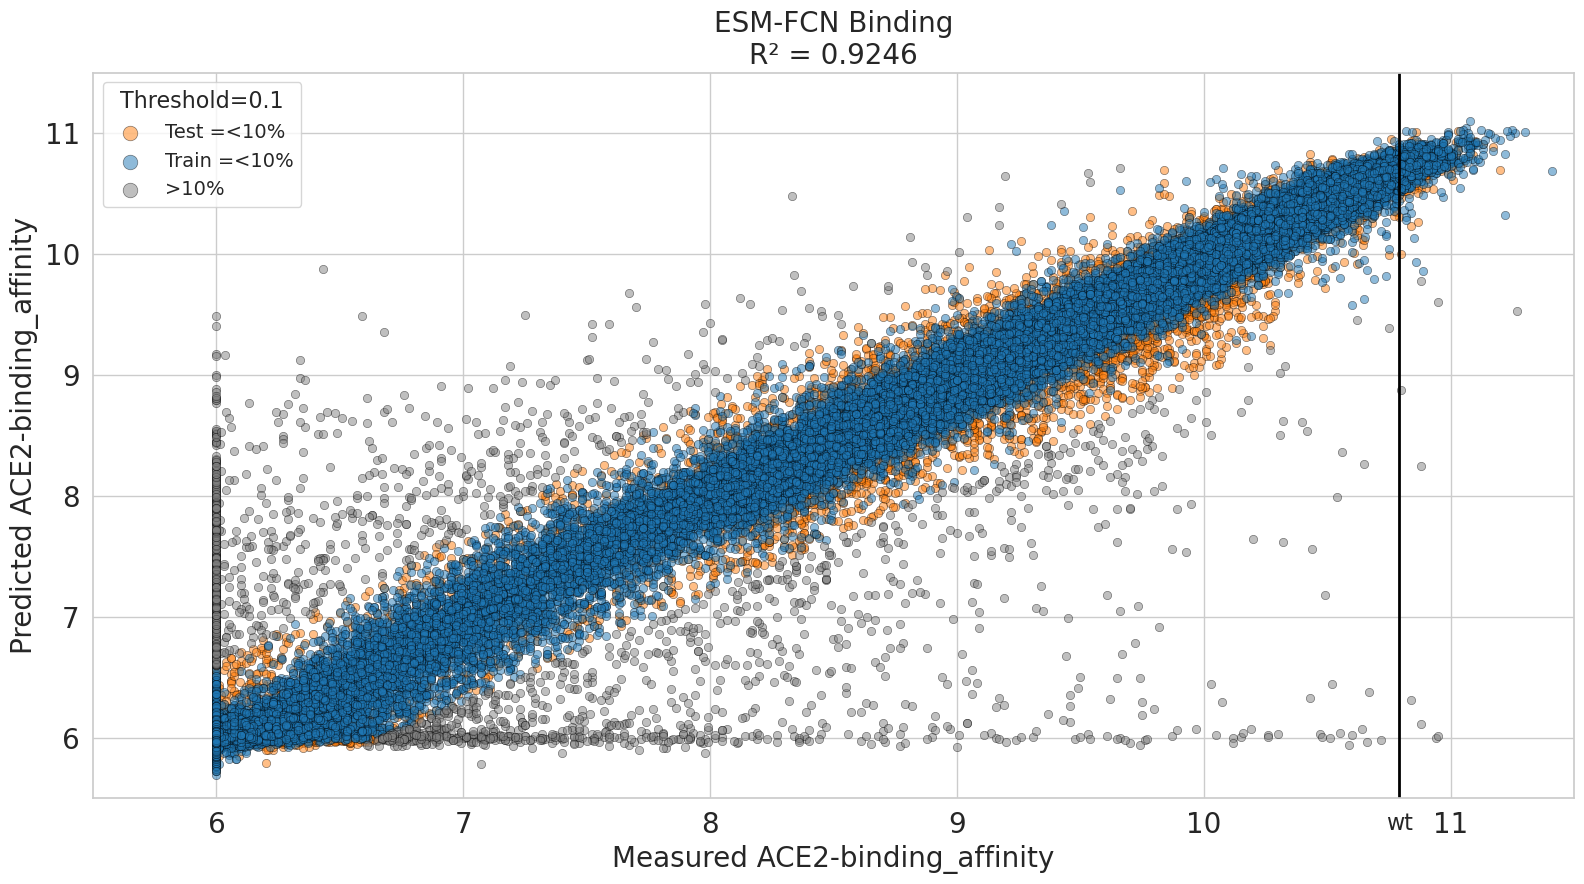

R^2: 0.900562450953455
R^2 outside of threshold: -0.2665091438536926
R^2 inside of threshold: 0.9257077118882684


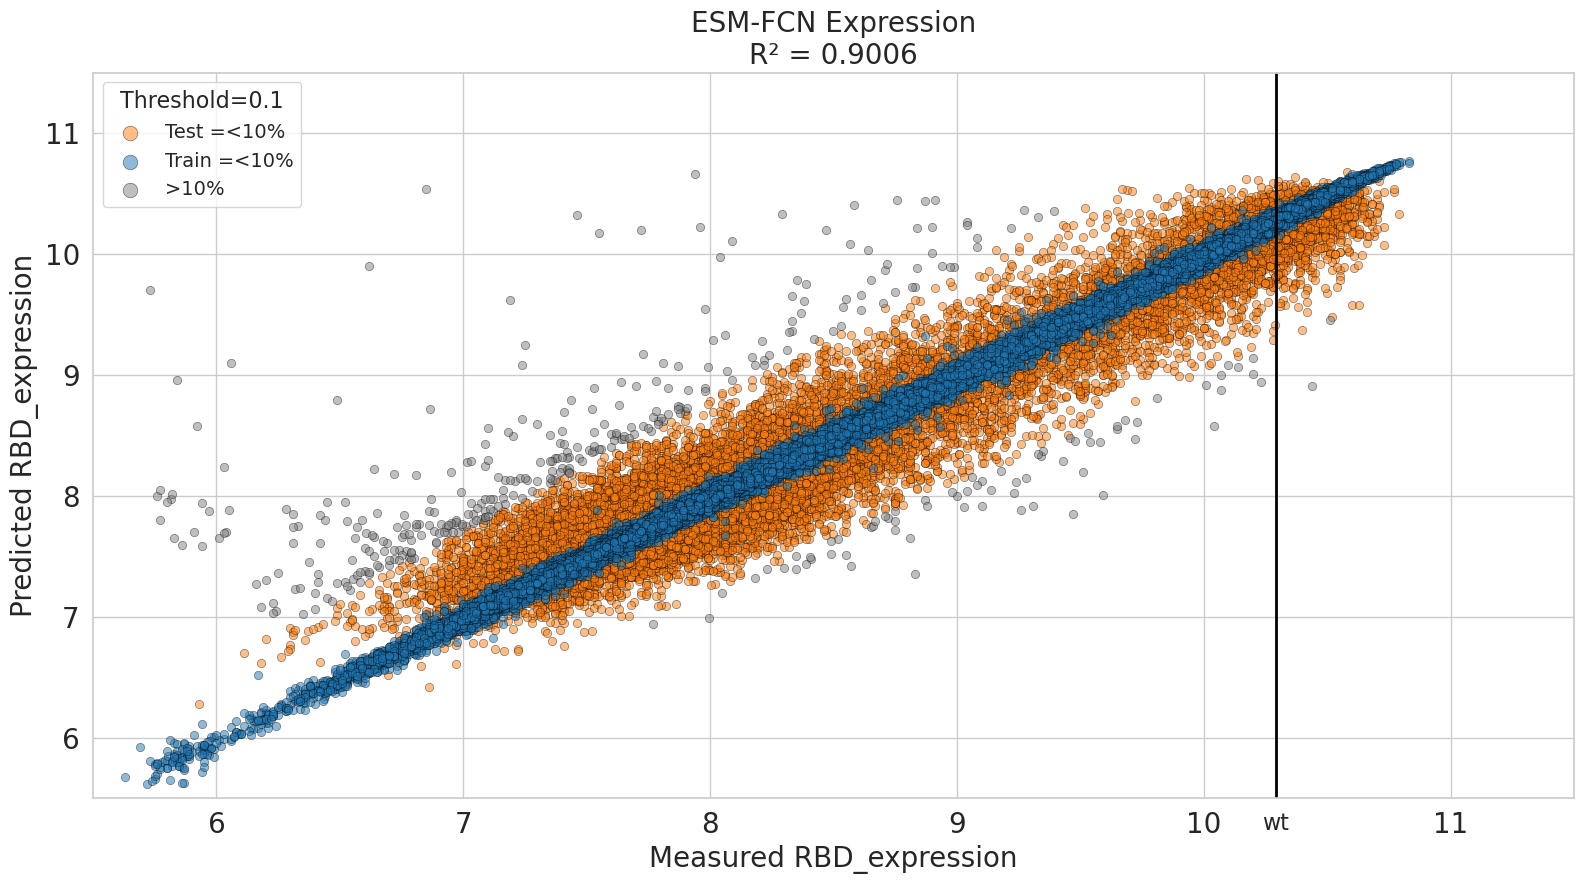

In [3]:
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-binding-2024-12-05_04-12/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_fcn_lr1e_04_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-FCN Binding", "../../results/plots/measured_vs_predicted/scatter/esm_fcn.lr1e-04.binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_fcn_lr1e_04_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-FCN Expression", "../../results/plots/measured_vs_predicted/scatter/esm_fcn.lr1e-04.expression-scatter.pdf", expression_wt)

### Non BE - LR = 1e-05

R^2: 0.926071185791218
R^2 outside of threshold: -0.8456412456921645
R^2 inside of threshold: 0.9877655230681235


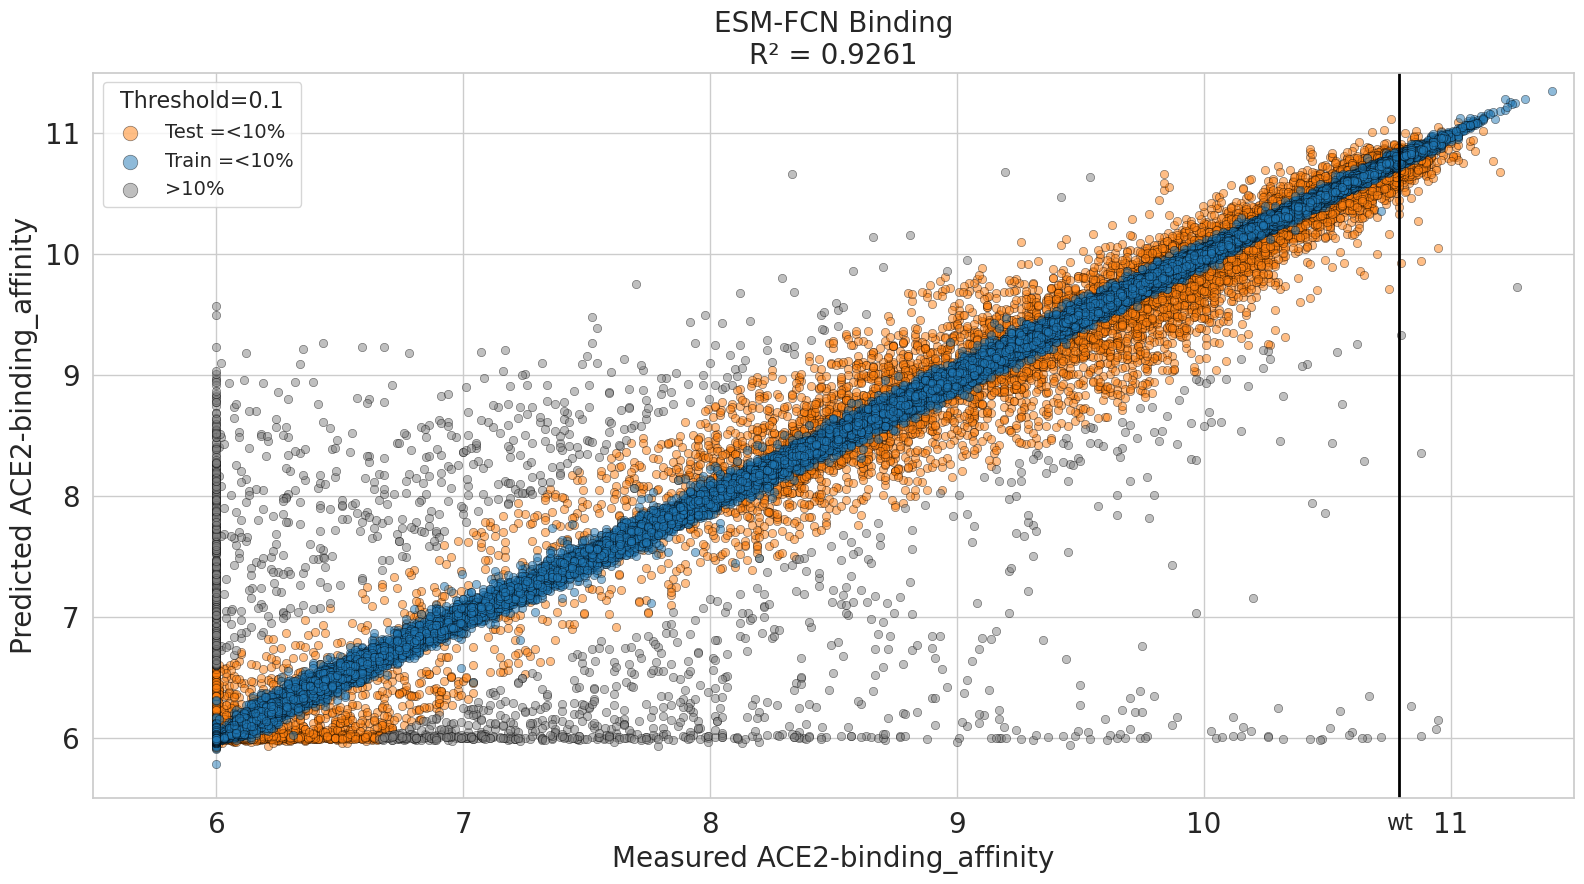

R^2: 0.898842939875
R^2 outside of threshold: -0.18146679691316536
R^2 inside of threshold: 0.9261693168856507


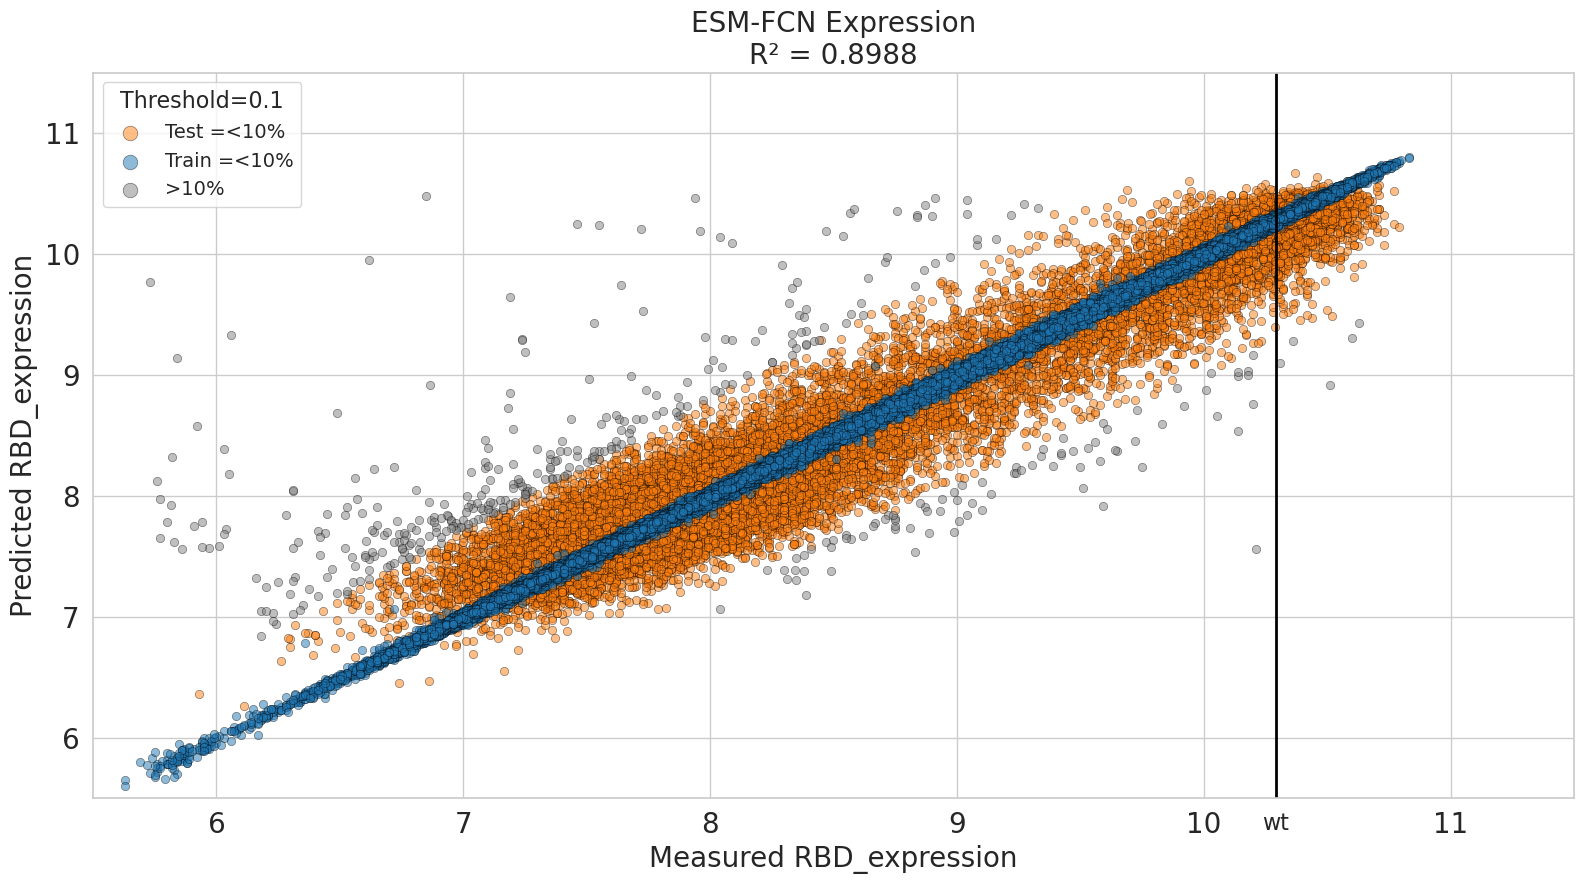

In [4]:
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_fcn_lr1e_05_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-FCN Binding", "../../results/plots/measured_vs_predicted/scatter/esm_fcn.lr1e-05.binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-expression-2024-12-04_17-56/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_fcn_lr1e_05_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-FCN Expression", "../../results/plots/measured_vs_predicted/scatter/esm_fcn.lr1e-05.expression-scatter.pdf", expression_wt)

### BE - LR = 1e-04

R^2: 0.9302888715946911
R^2 outside of threshold: -0.498596675263679
R^2 inside of threshold: 0.9873540855522771


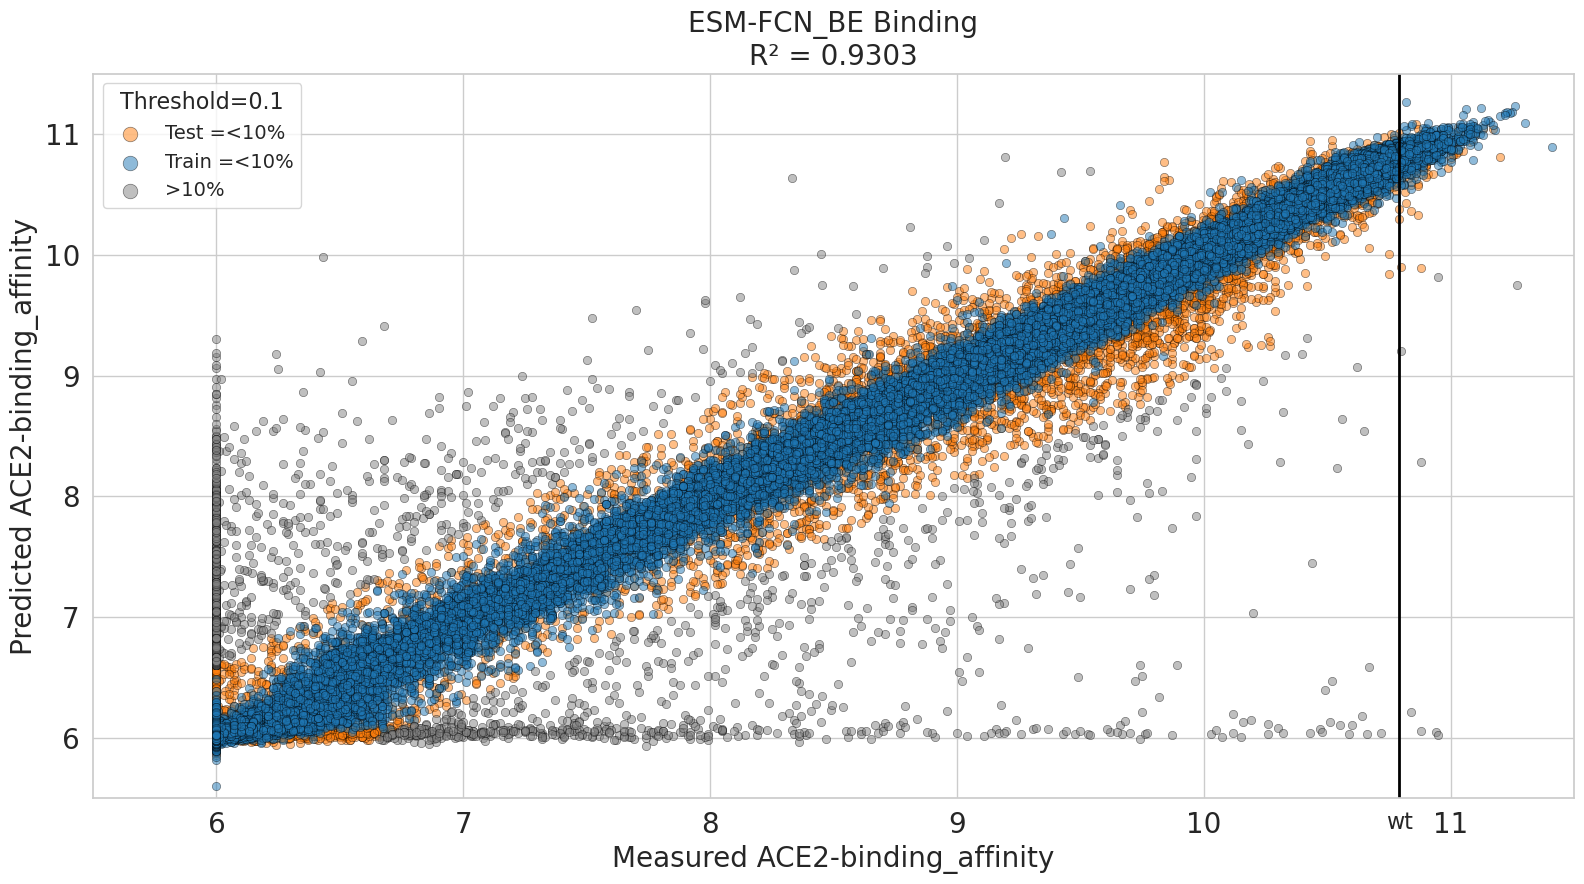

R^2: 0.8955222561742748
R^2 outside of threshold: -0.08913321661728757
R^2 inside of threshold: 0.9218743917099939


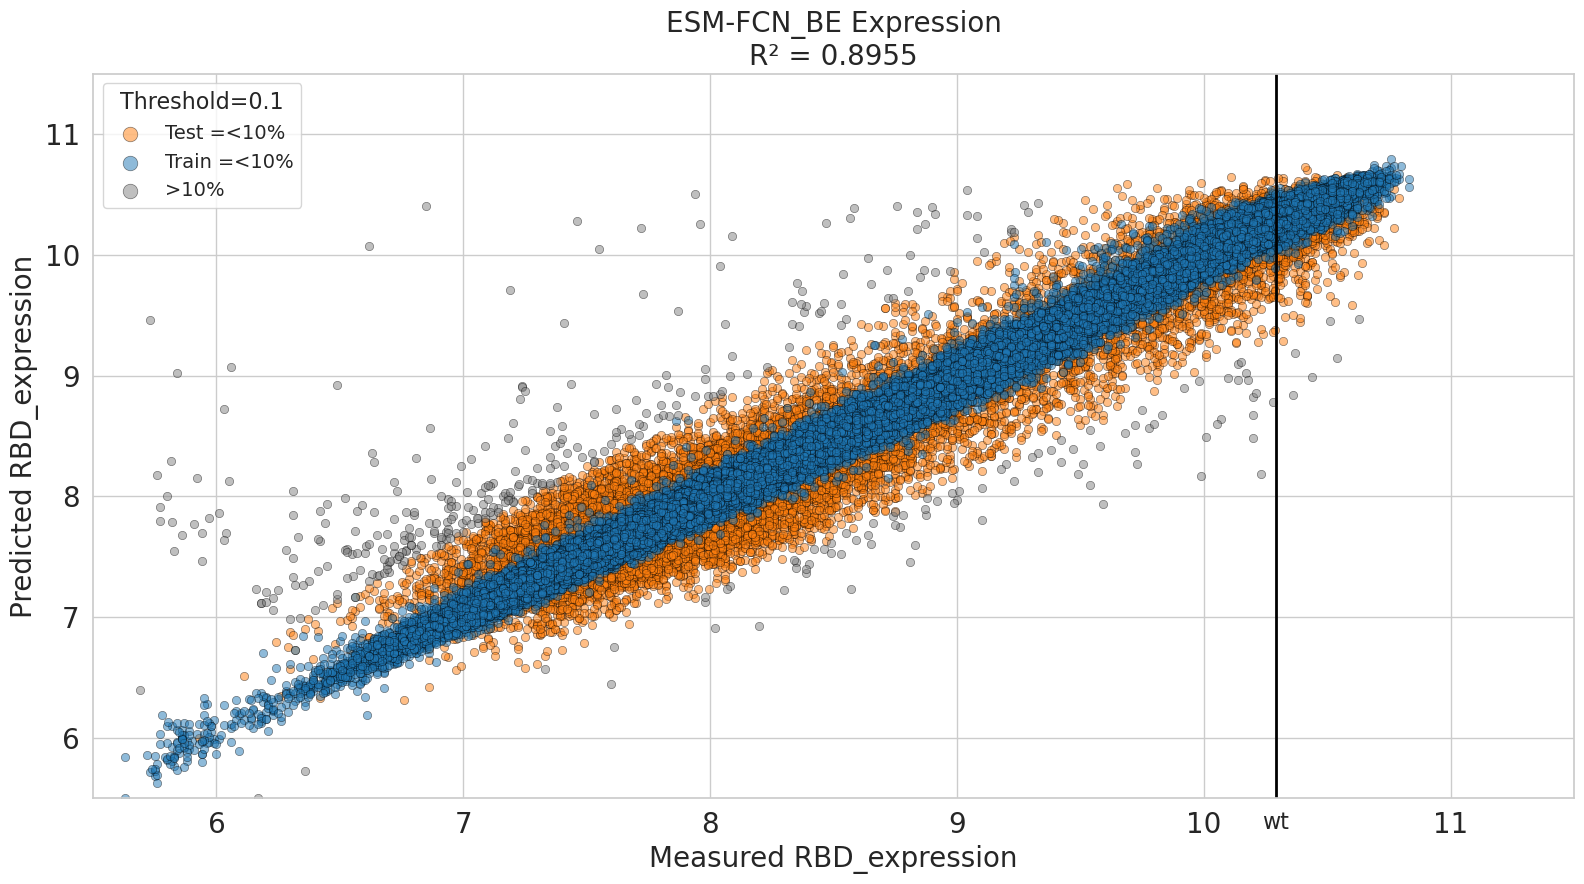

In [5]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_fcn_be_lr1e_04_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "binding_predicted_value", "ESM-FCN_BE Binding", "../../results/plots/measured_vs_predicted/scatter/esm_fcn_be.lr1e-04.binding-scatter.pdf", binding_wt)
esm_fcn_be_lr1e_04_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "expression_predicted_value", "ESM-FCN_BE Expression", "../../results/plots/measured_vs_predicted/scatter/esm_fcn_be.lr1e-04.expression-scatter.pdf", expression_wt)

### BE - LR = 1e-05

R^2: 0.9275202663972157
R^2 outside of threshold: -0.5394779981972178
R^2 inside of threshold: 0.9864925401764469


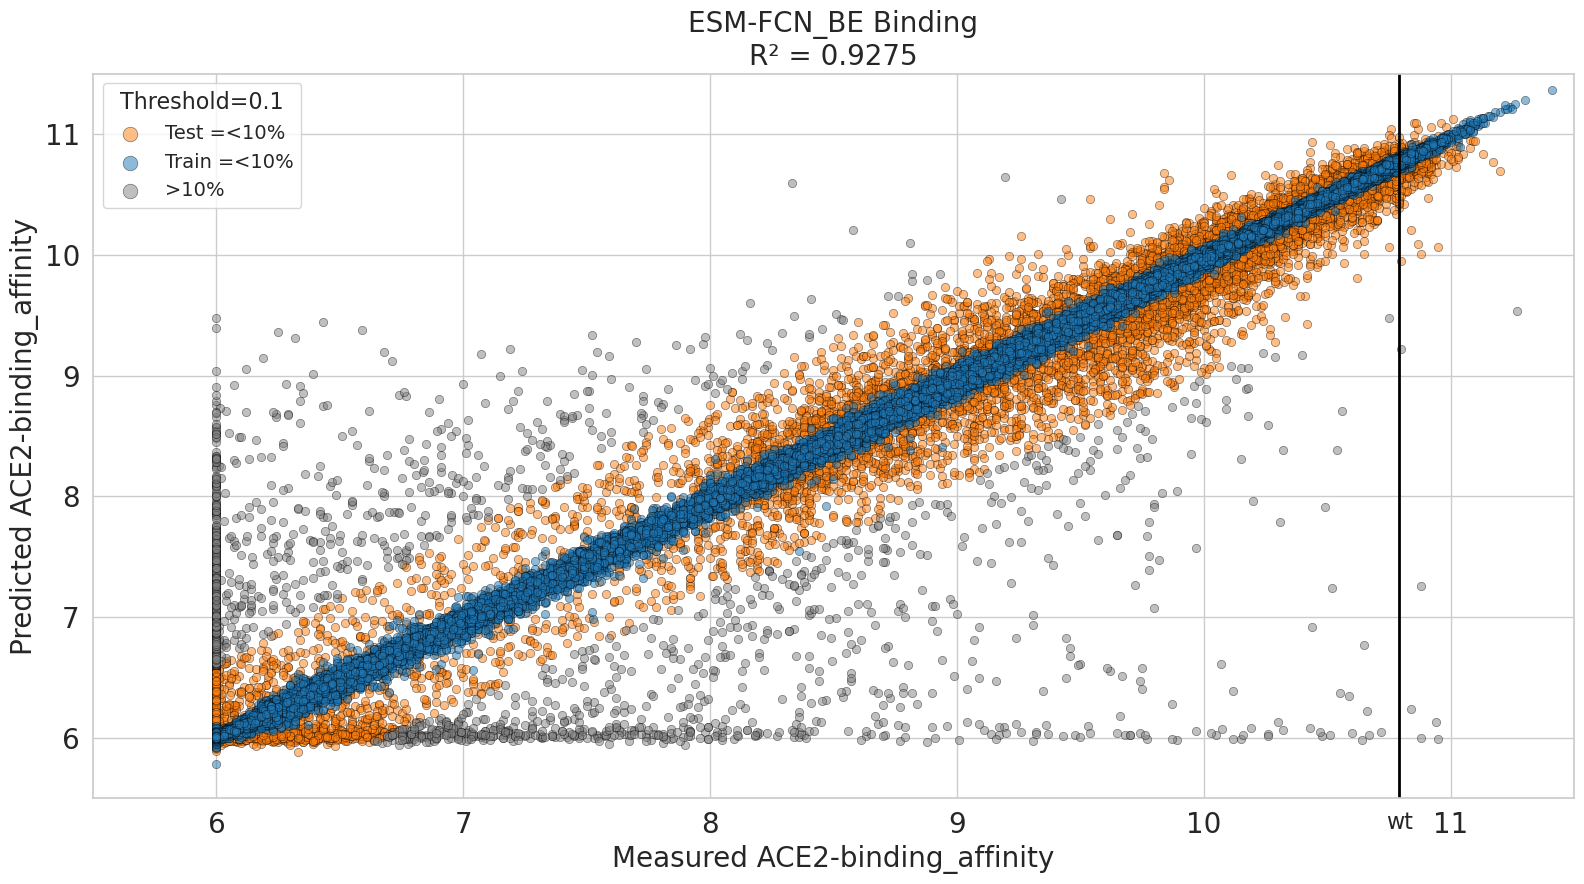

R^2: 0.8906468469607992
R^2 outside of threshold: 0.004198700116603837
R^2 inside of threshold: 0.9176419850503538


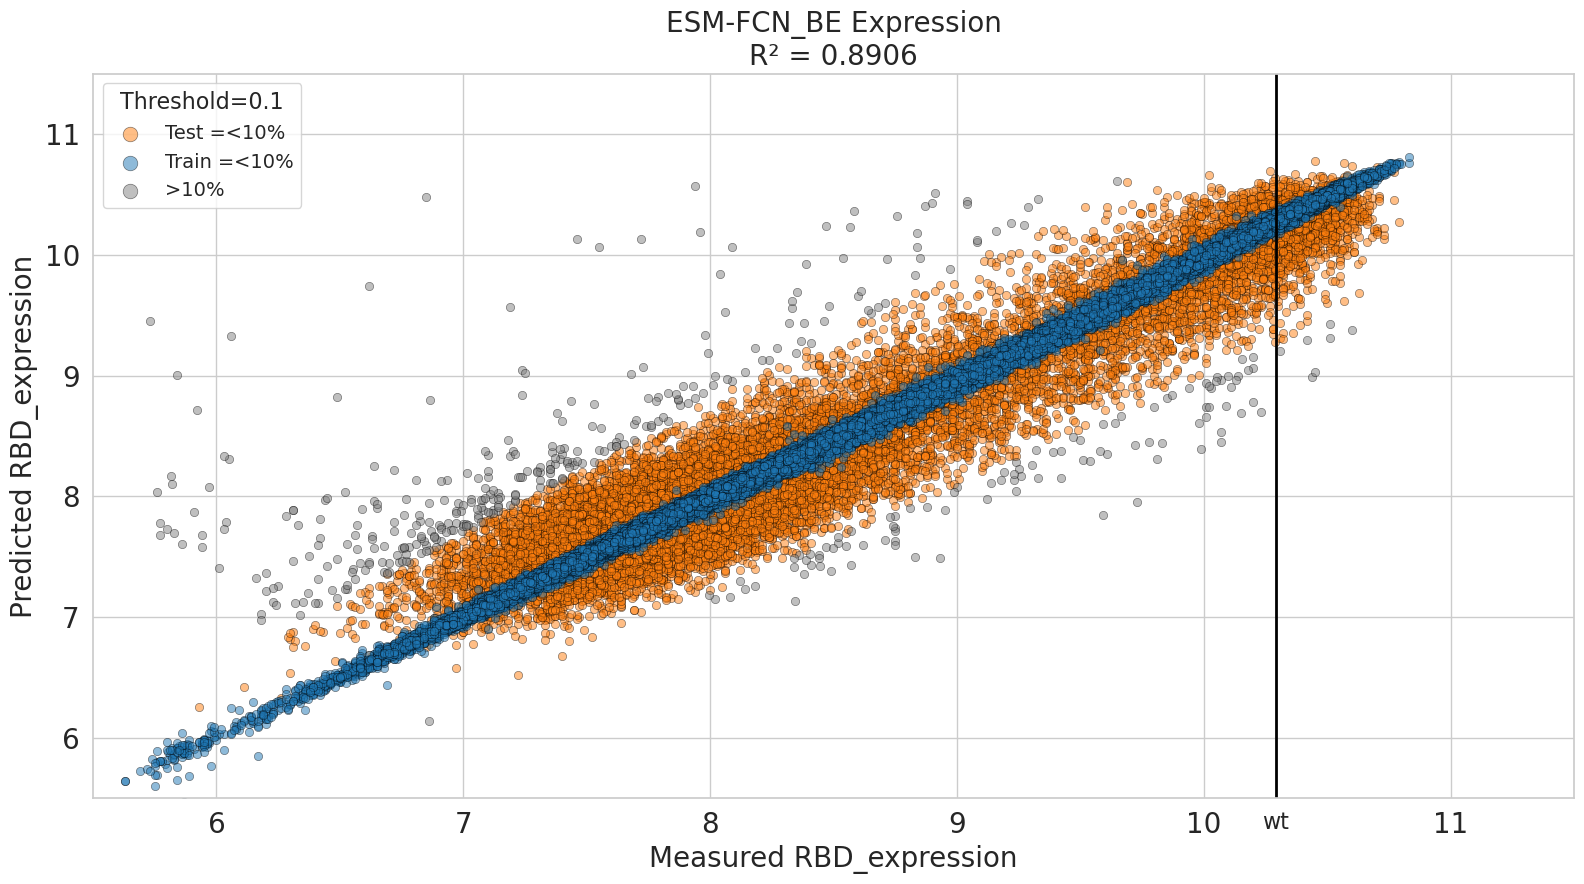

In [6]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn_BE-DMS_OLD-2025-01-01_22-45/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_fcn_be_lr1e_05_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "binding_predicted_value", "ESM-FCN_BE Binding", "../../results/plots/measured_vs_predicted/scatter/esm_fcn_be.lr1e-05.binding-scatter.pdf", binding_wt)
esm_fcn_be_lr1e_05_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "expression_predicted_value", "ESM-FCN_BE Expression", "../../results/plots/measured_vs_predicted/scatter/esm_fcn_be.lr1e-05.expression-scatter.pdf", expression_wt)

### Bar Chart

In [21]:
r2_dict = {
    "Separate\nLR=1e-04.binding": esm_fcn_lr1e_04_binding,
    "Separate\nLR=1e-04.expression": esm_fcn_lr1e_04_expression,
    "Separate\nLR=1e-05.binding": esm_fcn_lr1e_05_binding,
    "Separate\nLR=1e-05.expression": esm_fcn_lr1e_05_expression,
    "Combined\nLR=1e-04.binding": esm_fcn_be_lr1e_04_binding,
    "Combined\nLR=1e-04.expression": esm_fcn_be_lr1e_04_expression,
    "Combined\nLR=1e-05.binding": esm_fcn_be_lr1e_05_binding,
    "Combined\nLR=1e-05.expression": esm_fcn_be_lr1e_05_expression
}
print(r2_dict)

{'Separate\nLR=1e-04.binding': 0.9246497972694222, 'Separate\nLR=1e-04.expression': 0.900562450953455, 'Separate\nLR=1e-05.binding': 0.926071185791218, 'Separate\nLR=1e-05.expression': 0.898842939875, 'Combined\nLR=1e-04.binding': 0.9302888715946911, 'Combined\nLR=1e-04.expression': 0.8955222561742748, 'Combined\nLR=1e-05.binding': 0.9275202663972157, 'Combined\nLR=1e-05.expression': 0.8906468469607992}


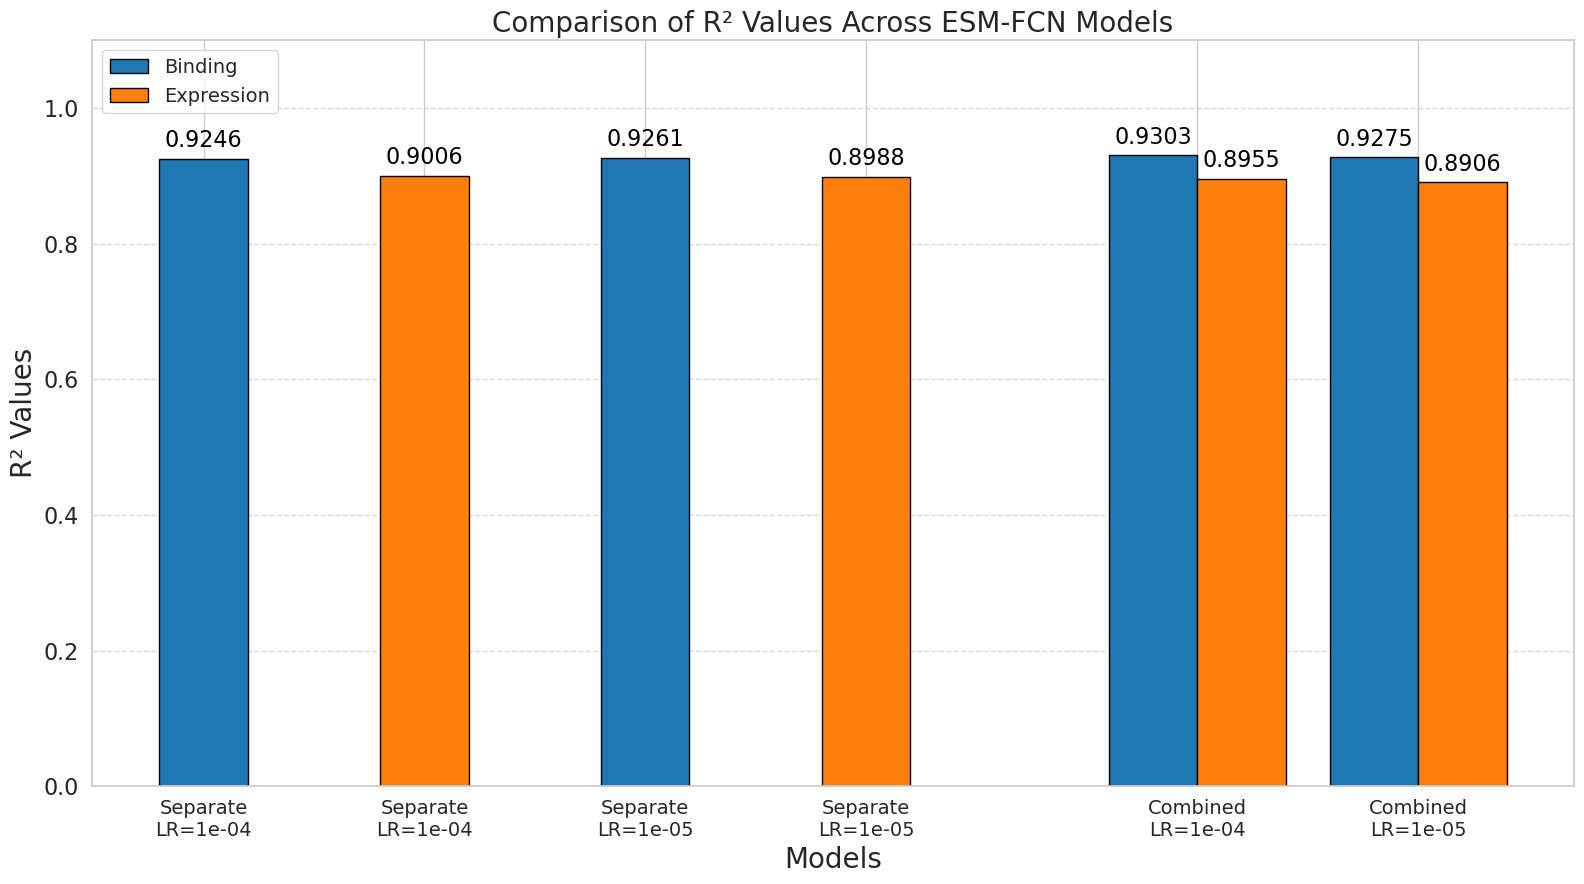

In [22]:
import matplotlib.pyplot as plt

# Define category groupings
individual_labels = ["Separate\nLR=1e-04", "Separate\nLR=1e-05"]
grouped_labels = ["Combined\nLR=1e-04", "Combined\nLR=1e-05"]

# Separate data
individual_models = []
individual_r2_values = []
grouped_models = []
grouped_r2_values_binding = []
grouped_r2_values_expression = []

for model, value in r2_dict.items():
    base_name = model.rsplit('.', 1)[0]  # Remove ".binding" or ".expression"
    if base_name in individual_labels:
        individual_models.append(model)
        individual_r2_values.append(value)
    elif base_name in grouped_labels:
        if "binding" in model:
            grouped_models.append(base_name)
            grouped_r2_values_binding.append(value)
        else:
            grouped_r2_values_expression.append(value)

fig, ax = plt.subplots(figsize=(16, 9))

# Plot individual bars separately
bar_width = 0.4
x_inds = np.arange(len(individual_models))
ax.bar(x_inds, individual_r2_values, color=['tab:blue' if 'binding' in model else 'tab:orange' for model in individual_models], edgecolor='black', width=bar_width)

# Plot grouped bars together
x_inds_grouped = np.arange(len(grouped_models)) + len(individual_models) + 0.5  # Separate from individual bars
binding_bars = ax.bar(x_inds_grouped - bar_width / 2, grouped_r2_values_binding, color='tab:blue', edgecolor='black', width=bar_width, label='Binding')
expression_bars = ax.bar(x_inds_grouped + bar_width / 2, grouped_r2_values_expression, color='tab:orange', edgecolor='black', width=bar_width, label='Expression')

# Set labels
all_labels = individual_models + grouped_labels
all_labels = [label.replace('.binding', '').replace('.expression', '') for label in all_labels]
ax.set_xticks(list(x_inds) + list(x_inds_grouped))
ax.set_xticklabels(all_labels, fontsize=14)
ax.tick_params(axis='y', labelsize=16)
ax.set_xlabel('Models', fontsize=20)
ax.set_ylabel('R² Values', fontsize=20)
ax.set_title('Comparison of R² Values Across ESM-FCN Models', fontsize=20)
ax.set_ylim(0, 1.1)  # R² values range from 0 to 1

# Add grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height + 0.01, f'{height:.4f}',
            ha='center', va='bottom', fontsize=16, color='black')

# Add legend with correct colors
ax.legend(fontsize=14, loc='upper left')

plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/bar/esm_fcn-bar_comp.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

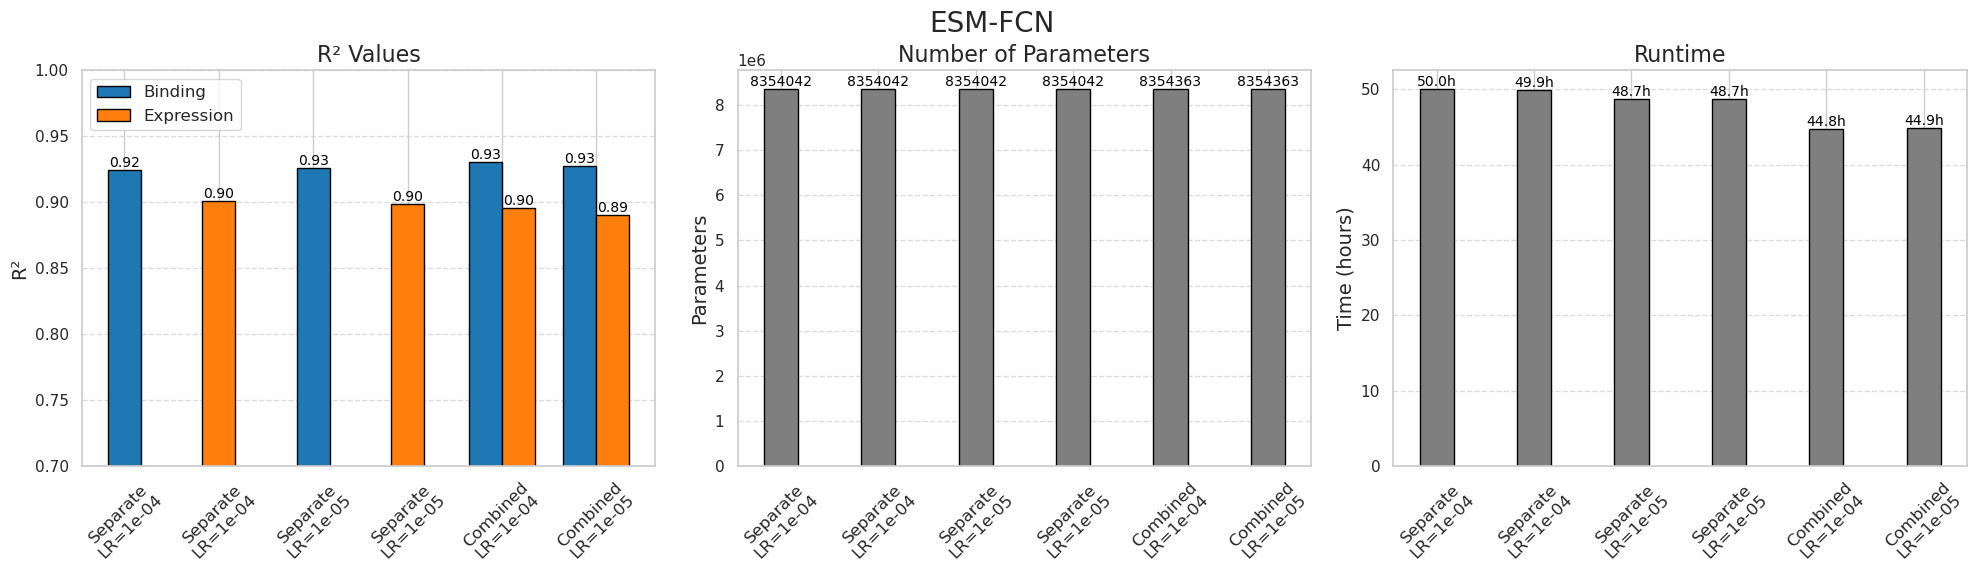

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# Data
r2_dict = {
    "Separate\nLR=1e-04.binding": esm_fcn_lr1e_04_binding,
    "Separate\nLR=1e-04.expression": esm_fcn_lr1e_04_expression,
    "Separate\nLR=1e-05.binding": esm_fcn_lr1e_05_binding,
    "Separate\nLR=1e-05.expression": esm_fcn_lr1e_05_expression,
    "Combined\nLR=1e-04.binding": esm_fcn_be_lr1e_04_binding,
    "Combined\nLR=1e-04.expression": esm_fcn_be_lr1e_04_expression,
    "Combined\nLR=1e-05.binding": esm_fcn_be_lr1e_05_binding,
    "Combined\nLR=1e-05.expression": esm_fcn_be_lr1e_05_expression
}

params_dict = {
    "Separate\nLR=1e-04.binding": 8354042,
    "Separate\nLR=1e-04.expression": 8354042,
    "Separate\nLR=1e-05.binding": 8354042,
    "Separate\nLR=1e-05.expression": 8354042,
    "Combined\nLR=1e-04.binding": 8354363,
    "Combined\nLR=1e-04.expression": 8354363,
    "Combined\nLR=1e-05.binding": 8354363,
    "Combined\nLR=1e-05.expression": 8354363
}

runtime_dict = {
    "Separate\nLR=1e-04.binding": "50:02:12",
    "Separate\nLR=1e-04.expression": "49:55:56",
    "Separate\nLR=1e-05.binding": "48:44:13",
    "Separate\nLR=1e-05.expression": "48:43:42",
    "Combined\nLR=1e-04.binding": "44:48:05",
    "Combined\nLR=1e-04.expression": "44:48:05",
    "Combined\nLR=1e-05.binding": "44:51:08",
    "Combined\nLR=1e-05.expression": "44:51:08"
}

def parse_extended_time(time_str):
    hours, minutes, seconds = map(int, time_str.split(':'))
    td = timedelta(hours=hours, minutes=minutes, seconds=seconds)
    return td.total_seconds() / 3600  # Convert to hours

# Convert runtime dictionary to hours
runtime_hours = {k: parse_extended_time(v) for k, v in runtime_dict.items()}

# Separate models and combined models
separate_models = sorted([k for k in r2_dict.keys() if "Separate" in k])
combined_models = sorted(list(set([k.rsplit(".", 1)[0] for k in r2_dict.keys() if "Combined" in k])))

# X indices
x_inds_sep = np.arange(len(separate_models))
x_inds_comb = np.arange(len(combined_models)) + len(separate_models)

# Bar width
bar_width = 0.35

# Colors
binding_color = 'tab:blue'
expression_color = 'tab:orange'

# Figure setup
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R² Plot
binding_legend = None
expression_legend = None

for i, model in enumerate(separate_models):
    color = binding_color if 'binding' in model else expression_color
    bar = axes[0].bar(x_inds_sep[i], r2_dict[model], color=color, edgecolor='black', width=bar_width)
    if 'binding' in model and binding_legend is None:
        binding_legend = bar
    elif 'expression' in model and expression_legend is None:
        expression_legend = bar

for i, model in enumerate(combined_models):
    binding_r2 = r2_dict[f"{model}.binding"]
    expression_r2 = r2_dict[f"{model}.expression"]
    axes[0].bar(x_inds_comb[i] - bar_width/2, binding_r2, color=binding_color, edgecolor='black', width=bar_width)
    axes[0].bar(x_inds_comb[i] + bar_width/2, expression_r2, color=expression_color, edgecolor='black', width=bar_width)

axes[0].set_title("R² Values", fontsize=16)
axes[0].set_ylabel("R²", fontsize=14)
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend([binding_legend, expression_legend], ["Binding", "Expression"], fontsize=12, loc="upper left")

# Parameters Plot
params_sep = [params_dict[m] for m in separate_models]
params_comb = [params_dict[f"{m}.binding"] for m in combined_models]

axes[1].bar(x_inds_sep, params_sep, color='tab:grey', edgecolor='black', width=bar_width)
axes[1].bar(x_inds_comb, params_comb, color='tab:grey', edgecolor='black', width=bar_width)
axes[1].set_title("Number of Parameters", fontsize=16)
axes[1].set_ylabel("Parameters", fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Runtime Plot
runtime_sep = [runtime_hours[m] for m in separate_models]
runtime_comb = [runtime_hours[f"{m}.binding"] for m in combined_models]

axes[2].bar(x_inds_sep, runtime_sep, color='tab:grey', edgecolor='black', width=bar_width)
axes[2].bar(x_inds_comb, runtime_comb, color='tab:grey', edgecolor='black', width=bar_width)
axes[2].set_title("Runtime", fontsize=16)
axes[2].set_ylabel("Time (hours)", fontsize=14)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Common x-axis labels
all_labels = separate_models + combined_models
all_labels = [label.replace('.binding', '').replace('.expression', '') for label in all_labels]
for ax in axes:
    ax.set_xticks(list(x_inds_sep) + list(x_inds_comb))
    ax.set_xticklabels(all_labels, fontsize=12, rotation=45)

# Add value labels on bars
for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        if ax == axes[2]:  # Runtime plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.1f}h',
                   ha='center', va='bottom', fontsize=10, color='black')
        elif ax == axes[1]:  # Parameter plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height}',
                   ha='center', va='bottom', fontsize=10, color='black')
        else:
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.2f}',
                   ha='center', va='bottom', fontsize=10, color='black')
            
fig.suptitle("ESM-FCN", fontsize=20, y=.95)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/bar/esm_fcn-bar_comp.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

## Frequent Mutations
Histogram figure of frequent mutations for ESM-FCN_BE. We'll choose this model because it was the best performing for both binding and expression.

In [47]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)

### Binding

In [66]:
# Binding
binding_df = merged_df[["seq_id", "binding_predicted_value", "ACE2-binding_affinity", "mode"]].copy()
binding_df["percentage_error"] = ((merged_df["binding_predicted_value"] - merged_df["ACE2-binding_affinity"]) / merged_df["ACE2-binding_affinity"]) * 100
binding_df

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-S19E_E141G_N157A,6.025325,6.000000,train,0.422088
1,SARS-CoV-2-T63F_Y178V_S184L,9.118689,9.160000,train,-0.450998
2,SARS-CoV-2-W106A_G146C,6.065585,6.000000,train,1.093086
3,SARS-CoV-2-A18C_R25V_L122T_P149R,6.147402,6.130000,train,0.283887
4,SARS-CoV-2-D59W_P96S,10.168621,10.160000,train,0.084853
...,...,...,...,...,...
102718,SARS-CoV-2-V11A_V32G_W106G_G146H,6.054747,6.000000,test,0.912444
102719,SARS-CoV-2-T3G_K48P_G83E_S147V_V173S,6.322847,6.000000,test,5.380781
102720,SARS-CoV-2-K94H,10.710976,10.718333,test,-0.068646
102721,SARS-CoV-2-T46L_S139T_F185Q,9.576644,9.320000,test,2.753690


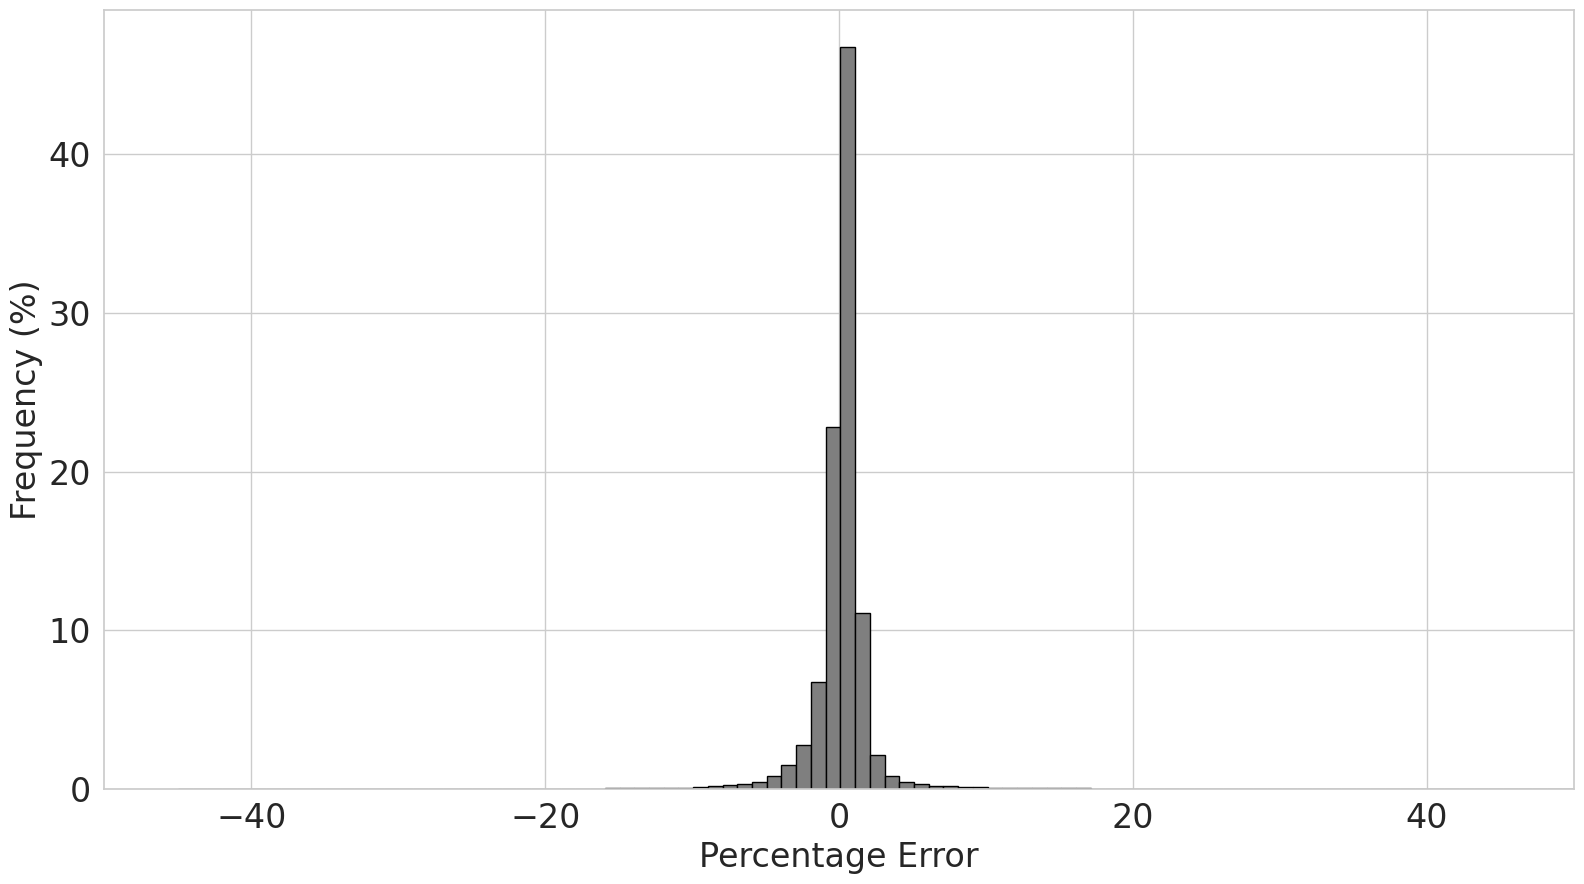

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 9))
plt.hist(
    binding_df["percentage_error"], 
    bins=100, 
    weights=[100 / len(binding_df)] * len(binding_df), 
    edgecolor='black', 
    color='tab:grey'
)

fontsize = 24
plt.xlim(-50, 50)  
plt.xlabel("Percentage Error", fontsize=fontsize)
plt.ylabel("Frequency (%)", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/scatter/esm_fcn_BE.lr1e-04.binding-percent_error_histogram.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

Now let's pull the outliers from top and bottom 2.5%.

In [68]:
lower_bound = binding_df['percentage_error'].quantile(0.025)
upper_bound = binding_df['percentage_error'].quantile(0.975)

outliers = binding_df[(binding_df['percentage_error'] < lower_bound) | (binding_df['percentage_error'] > upper_bound)].reset_index(drop=True)
outliers

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-D90T_R179H,7.640113,7.30,train,4.659081
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929
2,SARS-CoV-2-R127Q_Q144E,8.697819,8.24,train,5.556053
3,SARS-CoV-2-F12Y_F99A_A105S_A145V,6.144325,6.80,train,-9.642276
4,SARS-CoV-2-P54T_E141R,10.176861,9.38,train,8.495318
...,...,...,...,...,...
5133,SARS-CoV-2-I28A_S41N_C49W_C61N_K94A_F160G_N171Y,6.823151,6.00,test,13.719177
5134,SARS-CoV-2-N40L_L57C_T201S,9.697086,9.28,test,4.494465
5135,SARS-CoV-2-G86Y_K132R_Y175F,6.712379,7.95,test,-15.567560
5136,SARS-CoV-2-T3G_K48P_G83E_S147V_V173S,6.322847,6.00,test,5.380781


We need to adjust the seq_id to acquire the mutations from the data. 

The Spike receptor binding domain (RBD) from SARS-CoV-2 (isolate Wuhan-Hu-1, GenBank : MN908947, residues N331-T531) (checked [Deep Mutational Scanning of SARS-CoV-2 Receptor Binding Domain Reveals Constraints on Folding and ACE2 Binding](https://www.cell.com/cell/fulltext/S0092-8674(20)31003-5?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867420310035%3Fshowall%3Dtrue)). So we need to add 330 to get the RBD site (data not 0 indexed).

In [102]:
df = outliers.copy()
df['target'] = df['seq_id'].str.rsplit('-', n=1).str[0]
df['aa_substitutions'] = df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
print(len(df))

df = df.explode('aa_substitutions')
print(len(df))

df['RBD_mutation_site'] = df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 330 # Extract numeric site, RBD site
df['original_aa'] = df['aa_substitutions'].str[0]
df['new_aa'] = df['aa_substitutions'].str[-1]
df['aa_sub'] = df['original_aa'] + ">" + df['new_aa']
df.head(10)

5138
16906


,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-D90T_R179H,7.640113,7.30,train,4.659081,SARS-CoV-2,D90T,420,D,T,D>T
0,SARS-CoV-2-D90T_R179H,7.640113,7.30,train,4.659081,SARS-CoV-2,R179H,509,R,H,R>H
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,L95P,425,L,P,L>P
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,G116L,446,G,L,G>L
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,Y123E,453,Y,E,Y>E
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,Y143V,473,Y,V,Y>V
2,SARS-CoV-2-R127Q_Q144E,8.697819,8.24,train,5.556053,SARS-CoV-2,R127Q,457,R,Q,R>Q
2,SARS-CoV-2-R127Q_Q144E,8.697819,8.24,train,5.556053,SARS-CoV-2,Q144E,474,Q,E,Q>E
3,SARS-CoV-2-F12Y_F99A_A105S_A145V,6.144325,6.80,train,-9.642276,SARS-CoV-2,F12Y,342,F,Y,F>Y
3,SARS-CoV-2-F12Y_F99A_A105S_A145V,6.144325,6.80,train,-9.642276,SARS-CoV-2,F99A,429,F,A,F>A


Here we will look at the total mutations possible that occur at a particular site across all seq_ids in our outliers. Then we will break it down by amino acid.

In [103]:
from collections import Counter

original_aa_dict = df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
new_aa_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()

new_aa_total_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Per site total mutations: {new_aa_total_ct_dict}")

new_aa_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Per site, per new amino acid substitution total: {sorted_new_aa_ct_dict}")

Per site total mutations: {331: 101, 332: 118, 333: 123, 334: 86, 335: 158, 336: 148, 337: 84, 338: 92, 339: 156, 340: 92, 341: 70, 342: 113, 343: 90, 344: 140, 345: 98, 346: 51, 347: 60, 348: 56, 349: 80, 350: 67, 351: 42, 352: 53, 353: 76, 354: 41, 355: 58, 356: 43, 357: 59, 358: 73, 359: 38, 360: 36, 361: 49, 362: 44, 363: 105, 364: 103, 365: 123, 366: 85, 367: 120, 368: 75, 369: 71, 370: 62, 371: 127, 372: 102, 373: 79, 374: 141, 375: 121, 376: 59, 377: 58, 378: 67, 379: 120, 380: 90, 381: 92, 382: 50, 383: 51, 384: 65, 385: 117, 386: 127, 387: 83, 388: 70, 389: 102, 390: 134, 391: 221, 392: 77, 393: 106, 394: 104, 395: 34, 396: 48, 397: 39, 398: 99, 399: 57, 400: 37, 401: 50, 402: 46, 403: 45, 404: 42, 405: 23, 406: 54, 407: 84, 408: 40, 409: 8, 410: 30, 411: 93, 412: 99, 413: 145, 414: 96, 415: 88, 416: 145, 417: 149, 418: 72, 419: 162, 420: 227, 421: 153, 422: 52, 423: 66, 424: 148, 425: 123, 426: 146, 427: 139, 428: 156, 429: 167, 430: 142, 431: 44, 432: 42, 433: 167, 434: 125,

Let's make this into a proper table. 

In [104]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Possible Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

possible_mutations_per_site = pd.DataFrame(data)
print(possible_mutations_per_site.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                              Amino Acid Substitutions (Count)
      331                   N                       101                 L(16), S(11), K(10), M(7), E(7), Y(7), R(6), V(5), T(5), G(4), W(4), I(4), P(4), F(4), Q(3), D(2), H(1), C(1)
      332                   I                       118          T(14), L(13), V(12), S(12), N(7), K(7), F(6), R(6), G(6), M(5), A(5), H(4), Y(4), W(4), P(4), D(3), E(2), C(2), Q(2)
      333                   T                       123          S(16), L(13), R(11), N(10), P(8), F(7), C(6), V(6), E(6), I(5), D(5), M(5), G(5), W(5), K(5), H(3), A(3), Q(2), Y(2)
      334                   N                        86             S(11), T(9), R(7), L(7), P(7), Y(6), K(5), A(5), F(5), M(4), H(4), C(3), V(2), D(2), E(2), G(2), I(2), Q(2), W(1)
      335                   L                       158        T(17), R(17), S(15), Y(11),

Let's take a look at the top 10 sites with the highest total possible mutations occuring at that spot.

In [105]:
# Sort and display the top 10
possible_mutations_per_site['Total Possible Mutations'] = pd.to_numeric(possible_mutations_per_site['Total Possible Mutations'])
top_10_highest = possible_mutations_per_site.sort_values('Total Possible Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                              Amino Acid Substitutions (Count)
      531                   T                       230     R(29), S(27), K(23), L(21), V(19), M(14), Q(10), E(10), C(10), N(9), W(9), A(8), P(8), F(7), G(6), H(6), I(6), Y(5), D(3)
      420                   D                       227   R(25), S(23), N(19), Y(18), L(18), T(16), I(16), G(13), V(12), K(11), H(10), M(9), F(9), A(8), C(6), E(5), Q(4), W(4), P(1)
      391                   C                       221 S(20), K(17), V(16), R(15), M(15), I(13), P(12), A(12), T(12), L(11), F(11), Y(10), N(10), W(9), E(9), G(9), D(7), H(7), Q(6)
      436                   W                       213           L(28), R(27), S(24), V(17), T(16), I(12), K(11), C(11), M(10), N(9), A(8), Y(7), G(7), E(7), Q(6), P(5), D(4), F(4)
      437                   N                       200       L(22), T(22), P(20), S(19), 

Now, for each site we will grab the top 10 (as available) "binding_predicted_value" scores for each site. And then we will find the highest score predicted score per site. We save the measured value "ACE2-binding_affinity", and we can use this as a coordinate value associated with it's percentage error.

In [106]:
# Group by 'RBD_mutation_site' and extract top 10 binding_predicted_value scores for each site
top_p_scores_dict = df.groupby('RBD_mutation_site').apply(
    lambda x: x.nlargest(10, 'binding_predicted_value')[['new_aa', 'ACE2-binding_affinity', 'binding_predicted_value', 'percentage_error']].values.tolist()
).to_dict()

# Find the highest binding_predicted_value score and corresponding amino acid for each site
highest_p_scores = {site: max(scores, key=lambda x: x[2]) if scores else (None, 0, 0, 0) for site, scores in top_p_scores_dict.items()}

data = []
for site, max_score_info in highest_p_scores.items():
    total = new_aa_total_ct_dict[site]
    scores = top_p_scores_dict.get(site, [])
    scores_str = ', '.join([f'{aa}(({m_score:.2f}, {p_score:.2f}), {perc_error:.2f}%)' for aa, m_score, p_score, perc_error in scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'AA Sub with Highest Predicted Binding Value': max_score_info[0],
        'Highest Predicted Binding Value': f'{max_score_info[2]:.2f}',
        'PERC ERROR of Highest Predicted Binding Value': f'{max_score_info[3]:.2f}',
        'Measured and Predicted Binding Values ((m, p), %_err)': scores_str
    })

top_10_scores_per_site = pd.DataFrame(data)
print(top_10_scores_per_site.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid AA Sub with Highest Predicted Binding Value Highest Predicted Binding Value PERC ERROR of Highest Predicted Binding Value                                                                                                                                                                                                         Measured and Predicted Binding Values ((m, p), %_err)
      331              101                   N                                           L                           10.61                                          5.24       L((10.08, 10.61), 5.24%), F((9.69, 10.08), 4.04%), L((9.37, 9.91), 5.80%), S((9.39, 9.76), 3.97%), Y((7.98, 9.60), 20.28%), W((7.70, 9.54), 23.90%), R((8.87, 9.41), 6.05%), Q((10.27, 9.29), -9.55%), L((9.87, 9.19), -6.90%), T((9.62, 9.12), -5.24%)
      332              118                   I                                           S                           10.67                                

Top 10.

In [107]:
# Sort and display the top 10
top_10_scores_per_site['Highest Predicted Binding Value'] = pd.to_numeric(top_10_scores_per_site['Highest Predicted Binding Value'])
top_10_highest = top_10_scores_per_site.sort_values('Highest Predicted Binding Value', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid AA Sub with Highest Predicted Binding Value  Highest Predicted Binding Value PERC ERROR of Highest Predicted Binding Value                                                                                                                                                                                                        Measured and Predicted Binding Values ((m, p), %_err)
      413              145                   G                                           R                            11.27                                          4.15      R((10.82, 11.27), 4.15%), F((11.41, 10.89), -4.53%), I((8.96, 10.08), 12.47%), I((9.39, 9.90), 5.46%), K((9.31, 9.86), 5.88%), F((9.28, 9.83), 5.89%), V((9.43, 9.82), 4.18%), H((9.28, 9.75), 5.03%), R((10.29, 9.69), -5.81%), S((9.07, 9.53), 5.07%)
      455               51                   L                                           Q                            11.27                               

   position aa  impact
0       335  P  0.0494
1       384  L  0.0494
2       413  R  0.0415
3       455  Q  0.0415
4       459  C  0.0414
5       471  H  0.0412
6       503  N  0.1762
7       527  V  0.0412
8       528  S  0.1762
9       531  N -0.0453


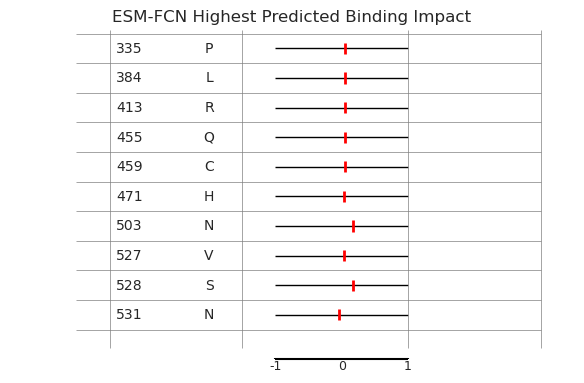

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Example Data
# ---------------------------------------------------

sorted_by_site = top_10_highest.sort_values('RBD Site', ascending=True).head(10)
positions = sorted_by_site['RBD Site'].to_list()
aas = sorted_by_site['AA Sub with Highest Predicted Binding Value'].to_list()
perc_errors = sorted_by_site['PERC ERROR of Highest Predicted Binding Value'].astype(float).to_list()
result = [error / 100 for error in perc_errors]

df = pd.DataFrame({
    'position': positions,
    'aa': aas,
    'impact': result
})
print(df)

# ---------------------------------------------------
# 2. Figure and Axes Setup
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# Hide the main axes (we will manually place text and lines)
ax.set_axis_off()

# Some layout parameters
x_text_col1 = -0.1   # X-position for the Position column text
x_text_col2 =  0.1   # X-position for the AA column text
x_bar_start =  0.3   # X-position where the bar starts (maps to -1)
bar_width    =  0.4  # Width of the bar region (maps to -1..1)

row_height = 0.8
# We'll invert the y-axis so that row 0 is at the top
y_top = row_height * (len(df) - 0.5)

# Make sure our axis limits encompass all we draw
ax.set_xlim(-0.5, 1.2)
# Leave some space at the bottom (for the custom tick labels)
ax.set_ylim(-1, y_top + 0.5)

# ---------------------------------------------------
# 3. Draw each row of the "table"
# ---------------------------------------------------
for i, (idx, row) in enumerate(df.iterrows()):
    # i goes from 0 to (len(df)-1)
    # We'll place the top row at the top and move downward.
    y_row = y_top - i*row_height

    # A) Position text (column 1)
    ax.text(x_text_col1, y_row, f"{row['position']}",
            va='center', ha='right', fontsize=10)

    # B) Amino acid text (column 2)
    ax.text(x_text_col2, y_row, f"{row['aa']}",
            va='center', ha='center', fontsize=10)

    # C) Horizontal bar for impact (column 3)
    #    The bar extends from -1 to 1, but we visually map that to
    #    x_bar_start -> x_bar_start+bar_width in this Axes.
    bar_left = x_bar_start
    bar_right = x_bar_start + bar_width
    ax.hlines(y_row, bar_left, bar_right, color='black', linewidth=1)

    # Vertical line for the impact value
    impact_val = row['impact']  # in [-1, 1]
    # Convert impact_val to [0..1] fraction across bar_width
    frac = (impact_val - (-1)) / 2.0  # 0.0 when -1, 1.0 when +1
    x_impact = bar_left + frac * bar_width

    ax.vlines(x_impact, y_row - 0.15, y_row + 0.15, color='red', linewidth=2)

# ---------------------------------------------------
# 4. (Optional) Draw table boundary lines
# ---------------------------------------------------
# Horizontal separators
for i in range(len(df)+1):
    y_line = y_top - (i-0.5)*row_height
    ax.hlines(y_line, -0.3, 1.1, color='gray', linewidth=0.5)

# Vertical separators (adjust x-positions to match how you placed text/bars)
for x_sep in [-0.2, 0.2, 0.7, 1.1]:
    ax.vlines(x_sep, -0.5, y_top + 0.5, color='gray', linewidth=0.5)

# ---------------------------------------------------
# 5. Add x-axis ticks at [-1, 0, 1] for the bar region
# ---------------------------------------------------
# We know x_bar_start (0.3) corresponds to -1, and (x_bar_start + bar_width) (0.7) corresponds to +1.
# So the halfway point (0.5) is 0.
tick_line_y = -0.8  # a bit below the bottom row
ax.hlines(tick_line_y, x_bar_start, x_bar_start + bar_width, color='black')  # horizontal axis line

tick_positions = [x_bar_start, x_bar_start + 0.5*bar_width, x_bar_start + bar_width]
tick_labels    = ['-1', '0', '1']

# Draw short vertical lines and label them
for xpos, tlabel in zip(tick_positions, tick_labels):
    ax.vlines(xpos, tick_line_y, tick_line_y + 0.03, color='black')
    ax.text(xpos, tick_line_y - 0.02, tlabel, ha='center', va='top', fontsize=9)

# ---------------------------------------------------
# 6. Show or Save the Figure
# ---------------------------------------------------
plt.title("ESM-FCN Highest Predicted Binding Impact")
plt.tight_layout()
plt.show()